## The Urgency List

The provisional watchlist from NB3 ranks purely by model similarity, which includes areas that are already 40-50% protected. This notebook adds an optional policy layer: an urgency score, oof_prob × (1 − milieu_anteil), that combines "looks designated" with "still unprotected" into one priority. 

It is explicitly a filtering device, not a model prediction — milieu_anteil never enters the model as a feature and is used here only to reweight the existing ranking, so this list is a downstream prioritisation of the validated watchlist, not a second model. The continuous share is drawn from the target notebook (NB0), where a value of zero is an observed "no protection", not a missing value.

In [1]:
#load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

In [2]:
#load the working data: XGBoost OOF probabilities + identifiers + geometries
xgb_oof = pd.read_csv("../../models/M_oof_xgboost.csv", dtype={"plr_id": str})

meta = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
meta = meta[["plr_id", "plr_name", "bez"]]

for d in (xgb_oof, meta):
    d["plr_id"] = d["plr_id"].astype(str).str.zfill(8)

#working table: oof_prob + y_true + names/district
df = xgb_oof.merge(meta, on="plr_id", how="left")

#PLR geometries (for the maps below)
gdf = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")
gdf["plr_id"] = gdf["plr_id"].astype(str).str.zfill(8)

#milieu_anteil — pulled in SEPARATELY, interpretation only, never a model feature
labels_full = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})
labels_full["plr_id"] = labels_full["plr_id"].astype(str).str.zfill(8)



In [3]:
#build the urgency base: undesignated PLR ranked by resemblance, with milieu_anteil attached

urgent_base = (
    df[df["y_true"] == 0]
    .merge(labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
    .sort_values("oof_prob", ascending=False)
    .reset_index(drop=True)
    [["plr_id", "plr_name", "bez", "oof_prob", "milieu_anteil"]]
)

#sanity
assert df["plr_name"].notna().all(), "some PLR did not get a name/district — check the merge"
print(f"{len(df)} PLR | {int(df['y_true'].sum())} designated | {int((df['y_true']==0).sum())} undesignated")
print(f"urgent_base: {len(urgent_base)} undesignated PLR (ranked by oof_prob, milieu_anteil attached)")

527 PLR | 109 designated | 418 undesignated
urgent_base: 418 undesignated PLR (ranked by oof_prob, milieu_anteil attached)


In [4]:
#check 2
urgent_base.index = urgent_base.index + 1
urgent_base.index.name = "rank"
print(urgent_base[["plr_name", "bez", "oof_prob", "milieu_anteil"]].to_string())


                          plr_name                              bez  oof_prob  milieu_anteil
rank                                                                                        
1                       Uferstraße                       01 - Mitte  0.999109   4.875236e-01
2                    Koloniestraße                       01 - Mitte  0.997601   2.211197e-01
3                      Arkonaplatz                       01 - Mitte  0.995976   9.594333e-04
4               Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505   4.956314e-01
5                      Stephankiez                       01 - Mitte  0.986148   3.832257e-01
6                      Schulstraße                       01 - Mitte  0.985959   2.382715e-01
7                Leon-Jessel-Platz  04 - Charlottenburg-Wilmersdorf  0.984600   0.000000e+00
8            Humboldthain Nordwest                       01 - Mitte  0.984006   1.296414e-01
9               Elberfelder Straße                       01 - Mitte  0

## Result 

Adding the variable milieu_anteil lets us see that some of the very high lookalikes are nearly 50% protected. This is why we create a variable that states clearly whether they are partially protected or effectively unprotected. 

In [5]:
def classify(a):
    if a < 0.10:
        return "effectively unprotected"   # early-warning candidate
    else:
        return "partially protected"       # protection started, substantial gap (up to the 50% gate)

urgent_base["status"] = urgent_base["milieu_anteil"].apply(classify)
print(urgent_base["status"].value_counts().to_string(), "\n")
print(urgent_base[["plr_name", "bez", "oof_prob", "milieu_anteil", "status"]].to_string())

status
effectively unprotected    368
partially protected         50 

                          plr_name                              bez  oof_prob  milieu_anteil                   status
rank                                                                                                                 
1                       Uferstraße                       01 - Mitte  0.999109   4.875236e-01      partially protected
2                    Koloniestraße                       01 - Mitte  0.997601   2.211197e-01      partially protected
3                      Arkonaplatz                       01 - Mitte  0.995976   9.594333e-04  effectively unprotected
4               Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505   4.956314e-01      partially protected
5                      Stephankiez                       01 - Mitte  0.986148   3.832257e-01      partially protected
6                      Schulstraße                       01 - Mitte  0.985959   2.382715e-01      parti

## Mapping the Urgency List


In [6]:
#milieu_anteil is from target_milieuschutz.csv — kept out of df on purpose
plot_geo2 = (
    gdf
    .merge(df[["plr_id", "oof_prob", "y_true"]], on="plr_id", how="left")   # plr_name NICHT aus df
    .merge(labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
)

#Plot 2: urgency only for UNDESIGNATED PLR; designated + non-modelled stay NaN (grey)
undes2 = (plot_geo2["y_true"] == 0)
plot_geo2["urgency"] = np.nan
plot_geo2.loc[undes2, "urgency"] = (
    plot_geo2.loc[undes2, "oof_prob"] * (1 - plot_geo2.loc[undes2, "milieu_anteil"])
)

#diagnostics: how many geometries got no model row (the ~15 dropped PLR)?
n_nomatch2 = plot_geo2["oof_prob"].isna().sum()
print(f"{len(plot_geo2)} geometries | {n_nomatch2} without a model row (dropped/uninhabited PLR)")
print(f"urgency range: {plot_geo2['urgency'].min():.3f} – {plot_geo2['urgency'].max():.3f}")

542 geometries | 15 without a model row (dropped/uninhabited PLR)
urgency range: 0.000 – 0.995


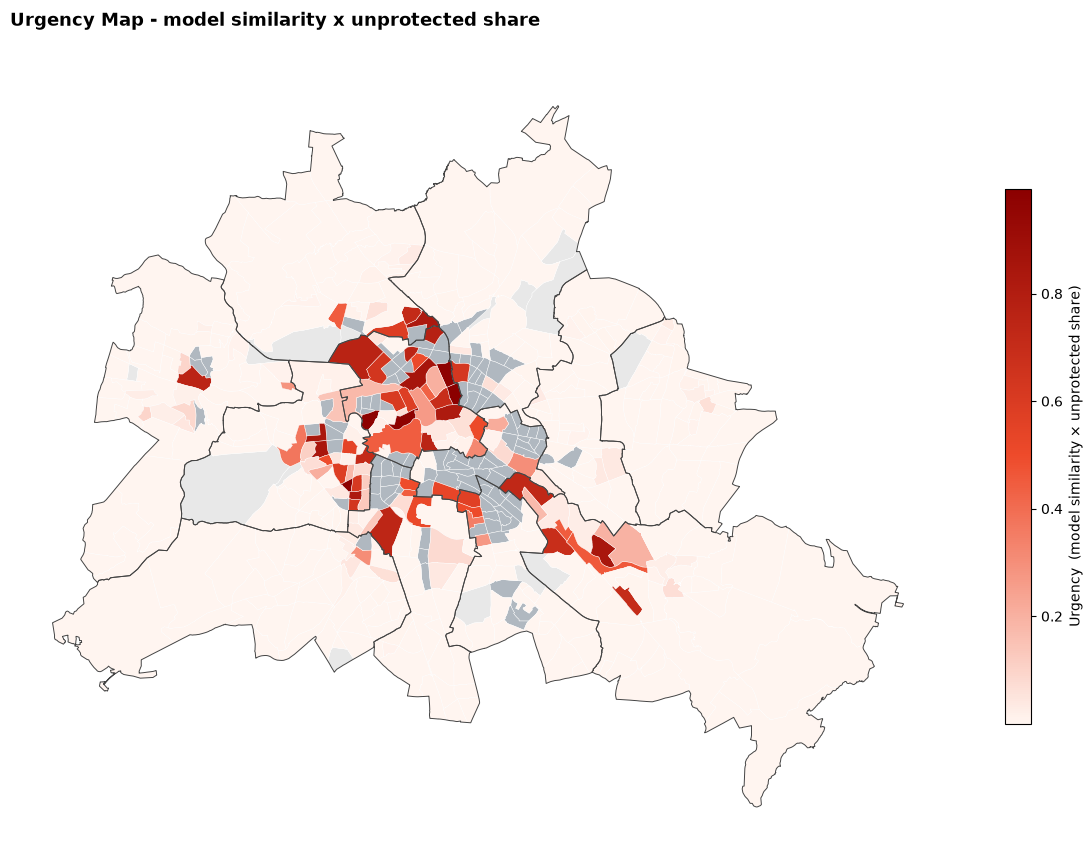

In [7]:
#plot2: urgency as model similarity x unprotected share 
#where is the early-warning value highest" — high similarity and little existing protection
fig, ax = plt.subplots(figsize=(12, 11))
red_cmap = LinearSegmentedColormap.from_list("kiez_red", ["#FFF5F0", "#EE4B2B", "#8B0000"])


#layer 1: all PLR as light grey base (so dropped + designated areas are visible, not holes)
plot_geo2.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#layer 2: designated PLR in a distinct neutral (already protected — not "urgent")
plot_geo2[plot_geo2["y_true"] == 1].plot(
    ax=ax, color="#b0b8c0", edgecolor="white", linewidth=0.3
)

#layer 3: undesignated PLR coloured by urgency (white -> red)
plot_geo2[undes2].plot(
    ax=ax, column="urgency", cmap=red_cmap, edgecolor="white", linewidth=0.3,
    legend=True, legend_kwds={"label": "Urgency  (model similarity × unprotected share)",
                              "shrink": 0.5}
)

#Bezirk outlines so the weak-fold districts are locatable
gdf.dissolve("bez").boundary.plot(ax=ax, color="#444444", linewidth=0.7)

ax.set_title("Urgency Map - model similarity x unprotected share\n",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_urgentsplot.png", dpi=200, bbox_inches="tight")
plt.show()

## Result: an early-warning signal beyond the inner ring

At first glance the urgency map barely differs from the resemblance surface: the same inner-ring cluster, the same south-eastern arm — and that near-identity is itself the finding. Because urgency multiplies resemblance by the unprotected share (1 − milieu_anteil), it only diverges where an area is both high-scoring and already substantially protected. Across most of the map those areas are rare, so the two rankings largely agree. 

Where the maps do differ is subtle but pointed: areas sitting just below the 50% protection threshold — near-designated cases like Uferstraße and Großgörschenstraße — fade on the urgency map even though they glow on the resemblance surface, because their unprotected share (1 − milieu_anteil) is small; they are already close to majority protection.

Conversely the south-eastern arm and the outer, entirely unprotected areas hold or intensify their colour, since a milieu_anteil near zero leaves their resemblance score undiscounted, which is why the urgency lens sharpens exactly the early-warning cases the watchlist is meant to surface.

## Comparison of the two Lists 

In [8]:
#where are the two lists differing? 
sub = plot_geo2[undes2].copy()
sub["rank_prob"] = sub["oof_prob"].rank(ascending=False)
sub["rank_urg"]  = sub["urgency"].rank(ascending=False)

wl = sub.nsmallest(25, "rank_prob")          
print(wl[["oof_prob", "milieu_anteil", "urgency"]]
      .assign(shift=wl["rank_prob"] - wl["rank_urg"])
      .sort_values("shift", key=abs, ascending=False)
      .head(10))

#does urgency pull anyone INTO the top 25 who wasn't there by oof_prob?
in_prob = set(sub.nsmallest(25, "rank_prob").index)
in_urg  = set(sub.nsmallest(25, "rank_urg").index)
entrants = sorted(in_urg - in_prob)          
print("only in oof top25:", sorted(in_prob - in_urg))
print("only in urgency top25:", entrants)

     oof_prob  milieu_anteil   urgency  shift
43   0.999109       0.487524  0.512020  -36.0
292  0.992505       0.495631  0.500588  -36.0
22   0.986148       0.383226  0.608231  -24.0
300  0.871418       0.484008  0.449644  -24.0
59   0.975650       0.453041  0.533641  -22.0
336  0.893927       0.434770  0.505274  -21.0
160  0.862824       0.018465  0.846893   15.0
194  0.823657       0.000000  0.823657   14.0
507  0.824959       0.000000  0.824959   14.0
126  0.963523       0.348877  0.627372  -13.0
only in oof top25: [22, 43, 59, 126, 292, 300, 336]
only in urgency top25: [4, 14, 186, 213, 384, 396, 508]


In [9]:
print("LEAVE (only in oof/resemblance top-25):")
print(sub.loc[[22,43,59,126,292,300,336], ["plr_name","bez","oof_prob","milieu_anteil","urgency"]]
      .sort_values("milieu_anteil", ascending=False).to_string())

print("\nENTER (only in urgency top-25):")
print(sub.loc[[4,14,186,213,384,396,508], ["plr_name","bez","oof_prob","milieu_anteil","urgency"]]
      .sort_values("oof_prob", ascending=False).to_string())

LEAVE (only in oof/resemblance top-25):
                   plr_name                            bez  oof_prob  milieu_anteil   urgency
292      Großgörschenstraße      07 - Tempelhof-Schöneberg  0.992505       0.495631  0.500588
43               Uferstraße                     01 - Mitte  0.999109       0.487524  0.512020
300    Hohenfriedbergstraße      07 - Tempelhof-Schöneberg  0.871418       0.484008  0.449644
59             Chamissokiez  02 - Friedrichshain-Kreuzberg  0.975650       0.453041  0.533641
336  Schillerpromenade Nord                  08 - Neukölln  0.893927       0.434770  0.505274
22              Stephankiez                     01 - Mitte  0.986148       0.383226  0.608231
126               Falkplatz                    03 - Pankow  0.963523       0.348877  0.627372

ENTER (only in urgency top-25):
                plr_name                              bez  oof_prob  milieu_anteil   urgency
213   Carl-Schurz-Straße                     05 - Spandau  0.766517   1.801573e-02

## Result: What the urgency reweighting changes

Discounting resemblance by existing protection swaps seven areas out of the top-25 and seven in: the entire practical footprint of the urgency layer. The seven that leave are all near-designated (milieu_anteil 0.35–0.50), including the two highest-scored areas in the whole ranking: Uferstraße (oof 0.999, milieu_anteil 0.49) and Großgörschenstraße (0.993, 0.50), whose scores the (1 − milieu_anteil) discount deliberately shrinks because protection is already largely in place. 

The seven that enter are the mirror image: moderate resemblance (oof_prob 0.69–0.77) but essentially unprotected (milieu_anteil ≈ 0) — spread across Spandau (Carl-Schurz-Straße), Reinickendorf (Breitkopfbecken), Treptow-Köpenick (Dörpfeldstraße West, Baumschulenweg West), Mitte (Wilhelmstraße, Invalidenstraße) and Charlottenburg-Wilmersdorf (Breitscheidplatz). 

The reweighting therefore does not overturn the ranking. It trades areas already on their way to protection for genuinely unprotected look-alikes; exactly the intent of the urgency framing.

In [ ]:
#check how many entrants are from the weak fold
#build sub FIRST
sub = plot_geo2[undes2].copy()

#strip the "NN - " prefix
sub["bez_name"] = sub["bez"].str.split(" - ").str[-1].str.strip()

#define what counts as weak fold
weak_fold_names = ["Charlottenburg-Wilmersdorf", "Lichtenberg"]

#pick the entrants and include bez_name in the columns
cols = ["bez", "bez_name", "oof_prob", "milieu_anteil", "urgency"]
entrant_rows = sub.loc[entrants, cols].copy()

#match on bez_name (stripped), NOT bez (prefixed)
entrant_rows["weak_fold"] = entrant_rows["bez_name"].isin(weak_fold_names)

entrant_rows = entrant_rows.sort_values("oof_prob", ascending=False)
print("only in urgency top25:", entrants)
print(entrant_rows)
print(f"\n{entrant_rows['weak_fold'].sum()} of {len(entrant_rows)} entrants sit in the weak fold")

only in urgency top25: [4, 14, 186, 213, 384, 396, 508]
                                 bez                    bez_name  oof_prob  \
213                     05 - Spandau                     Spandau  0.766517   
4                         01 - Mitte                       Mitte  0.756666   
186  04 - Charlottenburg-Wilmersdorf  Charlottenburg-Wilmersdorf  0.712941   
508               12 - Reinickendorf               Reinickendorf  0.712730   
396            09 - Treptow-Köpenick            Treptow-Köpenick  0.704122   
14                        01 - Mitte                       Mitte  0.693884   
384            09 - Treptow-Köpenick            Treptow-Köpenick  0.689616   

     milieu_anteil   urgency  weak_fold  
213   1.801573e-02  0.752708      False  
4     2.602949e-08  0.756666      False  
186   5.816938e-09  0.712941       True  
508   0.000000e+00  0.712730      False  
396   0.000000e+00  0.704122      False  
14    0.000000e+00  0.693884      False  
384   0.000000e+00  0.689

In [ ]:
#Export the urgencylist: top-25 undesignated PLR by urgency (oof_prob x unprotected share)
#This is the policy-facing shortlist (resemblance filtered by how much protection already exists).

N_URGENTLIST = 25

und = plot_geo2[undes2].copy()
# plr_name ist schon aus gdf da — KEIN zusätzlicher Merge mit df nötig
und["urgency"] = und["oof_prob"] * (1 - und["milieu_anteil"])
und["rank_urgency"] = und["urgency"].rank(ascending=False, method="min").astype(int)
und["status"] = und["milieu_anteil"].apply(classify)

urgencylist = (
    und[und["rank_urgency"] <= N_URGENTLIST]
    .sort_values("rank_urgency")
    [["plr_id", "plr_name", "bez", "oof_prob", "urgency", "milieu_anteil", "status", "rank_urgency"]]
    .reset_index(drop=True)
)

urgencylist.to_csv("../../models/M2_urgencylist.csv", index=False)
print(f"exported {len(urgencylist)} PLR (urgency top-{N_URGENTLIST}) -> M2_urgencylist.csv")
print(urgencylist.to_string(index=False))

exported 25 PLR (urgency top-25) -> M2_urgencylist.csv
  plr_id              plr_name                             bez  oof_prob  urgency  milieu_anteil                  status  rank_urgency
01100416           Arkonaplatz                      01 - Mitte  0.995976 0.995020   9.594333e-04 effectively unprotected             1
04501147     Leon-Jessel-Platz 04 - Charlottenburg-Wilmersdorf  0.984600 0.984600   0.000000e+00 effectively unprotected             2
01200522    Elberfelder Straße                      01 - Mitte  0.983263 0.983237   2.635215e-05 effectively unprotected             3
01200628     Lüneburger Straße                      01 - Mitte  0.979387 0.979387   0.000000e+00 effectively unprotected             4
01300834         Brunnenstraße                      01 - Mitte  0.976187 0.976047   1.430044e-04 effectively unprotected             5
01300836 Humboldthain Nordwest                      01 - Mitte  0.984006 0.856438   1.296414e-01     partially protected             6


## Caveats 

Two caveats apply to the urgency score. First, oof_prob and milieu_anteil are correlated by construction: the model is trained to predict designation (milieu_anteil > 0.5), so a PLR at 0.49 scores high precisely because it sits near the designation pattern, and urgency then multiplies that high score by a small (1 − 0.49). Under a filtering framing this is not a flaw but the intent: deliberately combining "looks designated" with "still unprotected" into one priority, but the two factors should not be read as independent signals confirming each other. 

Second, the 0.50 threshold is a hard gate: an area at 0.49 is scored, at 0.51 it drops off entirely. This is a defensible scope decision (majority-protected areas are outside the action space), and the (1 − milieu_anteil) weighting further encodes a contestable policy judgment, that urgency falls linearly with existing protection.

The practical stance is therefore to keep the watchlist (NB3) with oof_prob as the primary, statistically grounded ranking and to treat urgency as an explicitly labelled interpretive filter, not a model output. This distinction matters for validation: the underlying resemblance watchlist is what gets independently checked by Cleanlab (NB5) and by a regression (NB6). 

The urgency layer itself is not separately validated, because it is not an empirical claim to be tested but a policy weighting to be argued: multiplying by (1 − milieu_anteil) encodes a choice about how to prioritise, and that choice stands or falls on its transparency, not on a validation metric.